In [1]:
import cv2
from PIL import Image, ImageDraw
import clip
import torch
import numpy as np
import os

In [2]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

In [3]:
def retriev(elements, search_label: str) -> int:
    # process imgs
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    image_features /= image_features.norm(dim=-1, keepdim=True)

    # process labels
    label_features = []
    for label in search_label:
        preprocessed_label = torch.stack([preprocess(l).to(device) for l in label])
        label_feature = model.encode_image(preprocessed_label)
        label_feature /= label_feature.norm(dim=-1, keepdim=True)
        label_feature = torch.mean(label_feature, dim=0, keepdim=False)
        label_features.append(label_feature)
    label_features = torch.stack(label_features)

    # Calculate similar scores
    print(f"image_shape:{image_features.shape}")
    print(f"text_shape:{label_features.shape}")
    probs = 100. * image_features @ label_features.T
#     probs = 100. * label_features @ image_features.T
    print(f"image_text_shape: {probs.shape}")
    return probs[:, :].softmax(dim=-1)

In [4]:
def get_indices_of_values_above_threshold(values, threshold):
    indices = [-1] * values.shape[0]
    for i, n in enumerate(values):
        indice = torch.argmax(n)
        if n[indice] > threshold:
            indices[i] = indice  
            print(f"{indice}, {n[indice]}")
    return indices

In [5]:
label_dir = "/workspaces/assemblyhelper/labels"
labels = []
cls_list = os.listdir(label_dir)

for cls in cls_list:
    label = []
    path = os.path.join(label_dir, cls)
    imgs = os.listdir(path)
    for img in imgs:
        label.append(Image.open(os.path.join(path, img)))
    labels.append(label)

image_shape:torch.Size([1, 512])
text_shape:torch.Size([6, 512])
image_text_shape: torch.Size([1, 6])
tensor([[8.9407e-07, 9.1943e-01, 1.1325e-06, 8.0383e-02, 2.9802e-07, 0.0000e+00]],
       device='cuda:0', dtype=torch.float16, grad_fn=<SoftmaxBackward0>)
1, 0.91943359375
class: stringer


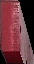

In [15]:
# image_dir = "/workspaces/assemblyhelper/cropped/parts/0"
# image_names = os.listdir(image_dir)
# image_list = []
# for name in image_names:
#     image_path = os.path.join(image_dir, name)
#     image_list.append(Image.open(image_path))

image_list = []
image_path = f"/workspaces/assemblyhelper/cropped/parts/0/5.png"
image_list.append(Image.open(image_path))
    
scores = retriev(image_list, labels)
print(scores)
indices = get_indices_of_values_above_threshold(scores, 0.05)

idx = 0
print(f"class: {cls_list[indices[idx]]}")
image_list[idx]

[tensor(3, device='cuda:0'), tensor(3, device='cuda:0')]
['warehouse', 'stringer', 'hand', 'signalinterfaceboard', 'battery', 'framework']


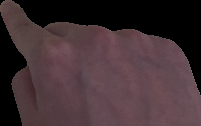

In [7]:
print(indices)
print(cls_list)
# print(labels[0])
labels[2][0]